# 🤖 Entrenamiento y Comparación de 5 Modelos ML
**Proyecto:** NexusDataCo – Sistema de Recomendación  
**Objetivo:** Predecir si un usuario realizará una **transacción** dado su historial de interacciones.

### Modelos evaluados:
| # | Modelo | Tipo |
|---|--------|------|
| 1 | Baseline (Popularidad) | Regla de negocio |
| 2 | Logistic Regression | Lineal |
| 3 | Random Forest | Ensemble (Bagging) |
| 4 | Gradient Boosting | Ensemble (Boosting) |
| 5 | SVD + Logistic | Factorización de Matrices |


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, roc_curve
)

from src.config import *
from src.data_cleaning import load_and_clean_events
from src.viz import setup_style
setup_style()

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 1️⃣ Carga y Preparación de Datos

In [2]:
path = EVENTS_CLEAN if os.path.exists(EVENTS_CLEAN) else EVENTS_RAW
print(f'Cargando: {path}')
df = load_and_clean_events(path)
print(f'Registros cargados: {len(df):,}')
df.head()

Cargando: C:\Users\DODY DUEÑAS\Documents\Proyecto Final\data\processed\events_clean.csv


Registros cargados: 2,755,641


,timestamp,visitorid,event,itemid,transactionid,datetime
0,1430622004384,693516,addtocart,297662,NaN,2015-05-03 03:00:04.384
1,1430622011289,829044,view,60987,NaN,2015-05-03 03:00:11.289
2,1430622013048,652699,view,252860,NaN,2015-05-03 03:00:13.048
3,1430622024154,1125936,view,33661,NaN,2015-05-03 03:00:24.154
4,1430622026228,693516,view,297662,NaN,2015-05-03 03:00:26.228


## 2️⃣ Feature Engineering

In [3]:
# ── Construir features de usuario-ítem ──
# Para cada usuario, calculamos:
# - n_views, n_addtocart, n_transactions (previas)
# - popularidad del ítem
# - recencia de la última interacción

print('Construyendo features de usuario...')
user_features = df.groupby('visitorid').agg(
    n_views        = ('event', lambda x: (x=='view').sum()),
    n_addtocart    = ('event', lambda x: (x=='addtocart').sum()),
    n_transactions = ('event', lambda x: (x=='transaction').sum()),
    n_items_unique = ('itemid', 'nunique'),
    n_interactions = ('event', 'count'),
).reset_index()

print('Construyendo features de ítem...')
item_features = df.groupby('itemid').agg(
    item_views       = ('event', lambda x: (x=='view').sum()),
    item_addtocart   = ('event', lambda x: (x=='addtocart').sum()),
    item_conversions = ('event', lambda x: (x=='transaction').sum()),
    item_popularity  = ('event', 'count'),
).reset_index()

# ── Unir features con el evento base ──
# Crear dataset: cada fila = (usuario, ítem, etiqueta)
# Etiqueta: 1 si el usuario compró el ítem, 0 si solo lo vio
print('Creando dataset con etiquetas...')

# Usar TODOS los datos disponibles (sin límite de muestreo)
df_sample = df[df['event'].isin(['view', 'transaction'])].copy()

df_sample['label'] = (df_sample['event'] == 'transaction').astype(int)

df_ml = df_sample.merge(user_features, on='visitorid', how='left')
df_ml = df_ml.merge(item_features, on='itemid', how='left')
df_ml.fillna(0, inplace=True)

print(f'Dataset ML: {df_ml.shape[0]:,} filas | Distribución etiquetas:')
print(df_ml['label'].value_counts().to_string())

Construyendo features de usuario...


Construyendo features de ítem...


Creando dataset con etiquetas...


Dataset ML: 2,686,675 filas | Distribución etiquetas:
label
0    2664218
1      22457


In [4]:
FEATURES = [
    'n_views', 'n_addtocart', 'n_items_unique', 'n_interactions',
    'item_views', 'item_addtocart', 'item_conversions', 'item_popularity'
]

X = df_ml[FEATURES].values
y = df_ml['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Positivos en test: {y_test.sum():,} ({y_test.mean()*100:.2f}%)')

Train: 2,149,340 | Test: 537,335
Positivos en test: 4,491 (0.84%)


---
## 3️⃣ Entrenamiento de los 5 Modelos

In [5]:
results = {}  # Almacenar métricas de todos los modelos

def evaluate(name, y_true, y_pred, y_prob, train_time):
    """Calcula métricas estándar y las guarda en results."""
    results[name] = {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob) if y_prob is not None else None,
        'Train_Time_s': round(train_time, 2),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }
    print(f'  ✅ {name:35s} | F1={results[name]["F1-Score"]:.4f} | AUC={results[name]["ROC-AUC"]:.4f} | t={train_time:.1f}s')
    return results[name]

print('=' * 80)
print('Entrenando modelos...')
print('=' * 80)

Entrenando modelos...


In [6]:
# ────────────────────────────────────────────
# MODELO 1: Baseline – Popularidad
# Predice siempre 1 si el ítem tiene >threshold transacciones
# ────────────────────────────────────────────
print('\n🔹 Modelo 1: Baseline (Popularidad)')
t0 = time.time()

# El índice 7 corresponde a item_popularity
thresh = np.percentile(X_test[:, 7], 75)
y_pred_base = (X_test[:, 7] > thresh).astype(int)
y_prob_base = X_test[:, 7] / (X_test[:, 7].max() + 1e-9)
t1 = time.time()

evaluate('1. Baseline (Popularidad)', y_test, y_pred_base, y_prob_base, t1-t0)


🔹 Modelo 1: Baseline (Popularidad)


  ✅ 1. Baseline (Popularidad)           | F1=0.0214 | AUC=0.6083 | t=0.0s


{'Accuracy': 0.7482185228954005,
 'Precision': 0.011049971590059512,
 'Recall': 0.32910264974393233,
 'F1-Score': 0.021382019139655834,
 'ROC-AUC': 0.6083090850919177,
 'Train_Time_s': 0.01,
 'y_pred': array([1, 1, 0, ..., 0, 0, 0], shape=(537335,)),
 'y_prob': array([0.06418523, 0.10082063, 0.00322392, ..., 0.00967175, 0.00293083,
        0.00058617], shape=(537335,))}

In [7]:
# ────────────────────────────────────────────
# MODELO 2: Logistic Regression
# ────────────────────────────────────────────
print('\n🔹 Modelo 2: Logistic Regression')
t0 = time.time()

lr = LogisticRegression(max_iter=300, class_weight='balanced', random_state=RANDOM_SEED, C=0.5)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
y_prob_lr = lr.predict_proba(X_test_s)[:, 1]
t1 = time.time()

evaluate('2. Logistic Regression', y_test, y_pred_lr, y_prob_lr, t1-t0)


🔹 Modelo 2: Logistic Regression


  ✅ 2. Logistic Regression              | F1=0.0860 | AUC=0.8804 | t=3.6s


{'Accuracy': 0.8879786353019997,
 'Precision': 0.0461345414249397,
 'Recall': 0.6303718548207526,
 'F1-Score': 0.08597676713992863,
 'ROC-AUC': 0.8803811184971965,
 'Train_Time_s': 3.63,
 'y_pred': array([0, 0, 0, ..., 0, 0, 0], shape=(537335,)),
 'y_prob': array([0.20005024, 0.16584017, 0.35810202, ..., 0.33944623, 0.35896083,
        0.36586348], shape=(537335,))}

In [8]:
# ────────────────────────────────────────────
# MODELO 3: Random Forest
# ────────────────────────────────────────────
print('\n🔹 Modelo 3: Random Forest')
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced',
    random_state=RANDOM_SEED, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
t1 = time.time()

evaluate('3. Random Forest', y_test, y_pred_rf, y_prob_rf, t1-t0)


🔹 Modelo 3: Random Forest


  ✅ 3. Random Forest                    | F1=0.1905 | AUC=0.9811 | t=86.6s


{'Accuracy': 0.9307750286134349,
 'Precision': 0.10555260745815041,
 'Recall': 0.974393230906257,
 'F1-Score': 0.1904720450934732,
 'ROC-AUC': 0.9811375358735327,
 'Train_Time_s': 86.64,
 'y_pred': array([0, 1, 0, ..., 0, 0, 0], shape=(537335,)),
 'y_prob': array([0.00140347, 0.65538734, 0.        , ..., 0.        , 0.        ,
        0.        ], shape=(537335,))}

In [9]:
# ────────────────────────────────────────────
# MODELO 4: Gradient Boosting
# ────────────────────────────────────────────
print('\n🔹 Modelo 4: Gradient Boosting')
t0 = time.time()

gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=RANDOM_SEED
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]
t1 = time.time()

evaluate('4. Gradient Boosting', y_test, y_pred_gb, y_prob_gb, t1-t0)


🔹 Modelo 4: Gradient Boosting


  ✅ 4. Gradient Boosting                | F1=0.1334 | AUC=0.9832 | t=386.6s


{'Accuracy': 0.9919454344124243,
 'Precision': 0.6620278330019881,
 'Recall': 0.07414829659318638,
 'F1-Score': 0.13336003203844612,
 'ROC-AUC': 0.9832185208285315,
 'Train_Time_s': 386.56,
 'y_pred': array([0, 0, 0, ..., 0, 0, 0], shape=(537335,)),
 'y_prob': array([1.79070844e-04, 2.95975511e-02, 6.73457596e-05, ...,
        6.76012827e-05, 6.73457596e-05, 6.73457596e-05], shape=(537335,))}

In [10]:
# ────────────────────────────────────────────
# MODELO 5: SVD + Logistic Regression (Matrix Factorization)
# ────────────────────────────────────────────
print('\n🔹 Modelo 5: SVD + Logistic Regression')
t0 = time.time()

n_components = X_train.shape[1]  # Todos los componentes (features)
svd_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svd',    TruncatedSVD(n_components=n_components, random_state=RANDOM_SEED)),
    ('lr',     LogisticRegression(max_iter=300, class_weight='balanced', C=0.5, random_state=RANDOM_SEED))
])
svd_pipe.fit(X_train, y_train)
y_pred_svd = svd_pipe.predict(X_test)
y_prob_svd = svd_pipe.predict_proba(X_test)[:, 1]
t1 = time.time()

evaluate('5. SVD + Logistic (Matrix Factor.)', y_test, y_pred_svd, y_prob_svd, t1-t0)

print('\n✅ Todos los modelos entrenados')


🔹 Modelo 5: SVD + Logistic Regression


  ✅ 5. SVD + Logistic (Matrix Factor.)  | F1=0.0876 | AUC=0.8824 | t=9.7s

✅ Todos los modelos entrenados


---
## 4️⃣ Tabla de Comparación de Métricas

In [11]:
metrics_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','Train_Time_s']
df_results = pd.DataFrame(
    {name: {k: v for k,v in vals.items() if k in metrics_cols}
     for name, vals in results.items()}
).T.astype(float).round(4)

# Color: resaltar mejor valor por columna
display(df_results.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'], color='#2ecc71')
    .highlight_min(subset=['Train_Time_s'], color='#3498db')
    .format('{:.4f}')
    .set_caption('Comparación de Modelos – NexusDataCo')
)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train_Time_s
1. Baseline (Popularidad),0.7482,0.0110,0.3291,0.0214,0.6083,0.0100
2. Logistic Regression,0.8880,0.0461,0.6304,0.0860,0.8804,3.6300
3. Random Forest,0.9308,0.1056,0.9744,0.1905,0.9811,86.6400
4. Gradient Boosting,0.9919,0.6620,0.0741,0.1334,0.9832,386.5600
5. SVD + Logistic (Matrix Factor.),0.8903,0.0471,0.6304,0.0876,0.8824,9.6600


## 5️⃣ Comparación Visual de Métricas

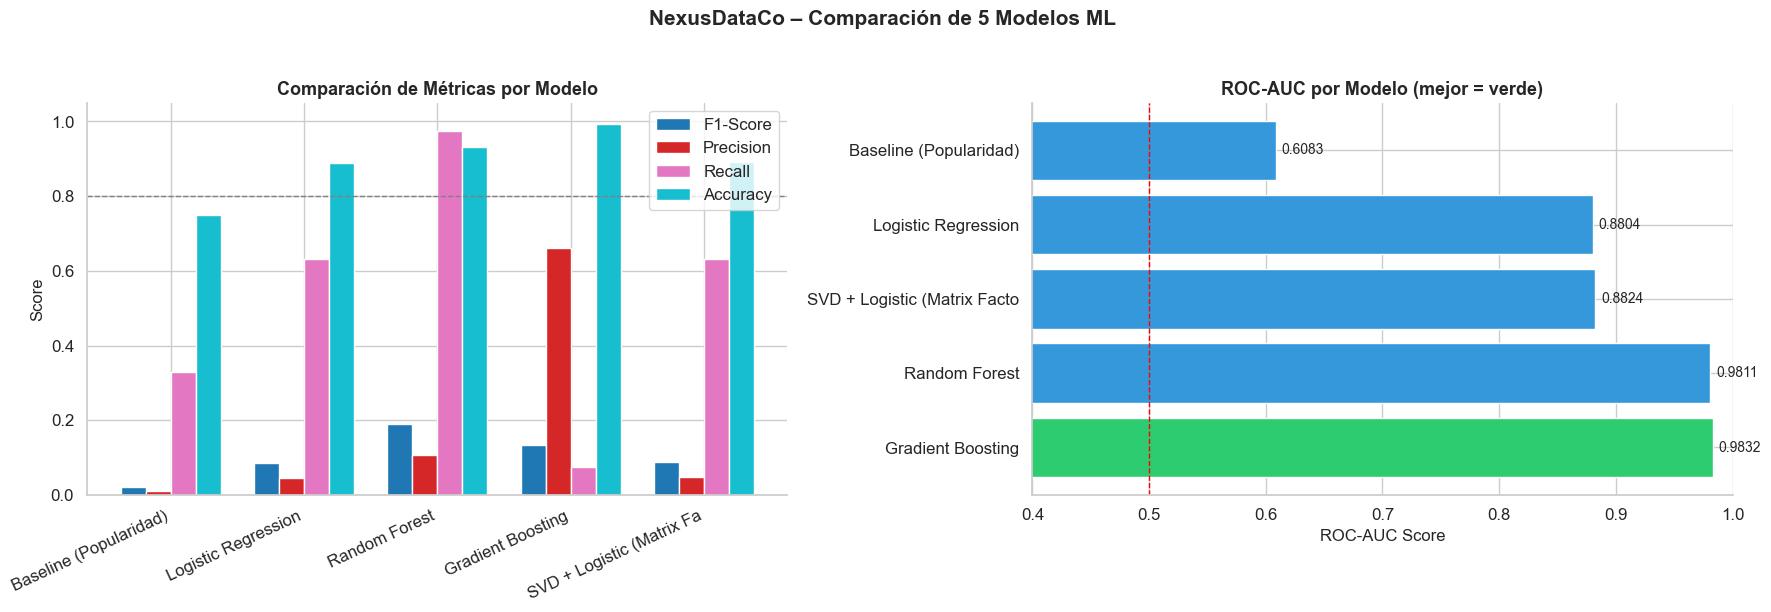

In [12]:
# ── Gráfica 1: Barplot comparativo de F1, Precision, Recall, AUC ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

metrics_to_plot = ['F1-Score','Precision','Recall','Accuracy']
df_plot = df_results[metrics_to_plot]
short_names = [n.split('.')[1].strip()[:25] for n in df_results.index]

df_plot.set_index(pd.Index(short_names)).plot(
    kind='bar', ax=axes[0], colormap='tab10', edgecolor='white', width=0.75
)
axes[0].set_title('Comparación de Métricas por Modelo', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 1.05)
axes[0].set_xticklabels(short_names, rotation=25, ha='right')
axes[0].legend(loc='upper right')
axes[0].axhline(0.8, color='gray', lw=1, ls='--', label='Umbral 0.8')

# ── Gráfica 2: ROC-AUC barplot ──
auc_vals = df_results['ROC-AUC'].sort_values(ascending=False)
colors   = ['#2ecc71' if v == auc_vals.max() else '#3498db' for v in auc_vals]
axes[1].barh(range(len(auc_vals)), auc_vals.values, color=colors, edgecolor='white')
axes[1].set_yticks(range(len(auc_vals)))
axes[1].set_yticklabels([n.split('.')[1].strip()[:28] for n in auc_vals.index])
axes[1].set_xlim(0.4, 1.0)
for i, v in enumerate(auc_vals.values):
    axes[1].text(v+0.005, i, f'{v:.4f}', va='center', fontsize=10)
axes[1].set_title('ROC-AUC por Modelo (mejor = verde)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('ROC-AUC Score')
axes[1].axvline(0.5, color='red', lw=1, ls='--')

plt.suptitle('NexusDataCo – Comparación de 5 Modelos ML', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 6️⃣ Curvas ROC

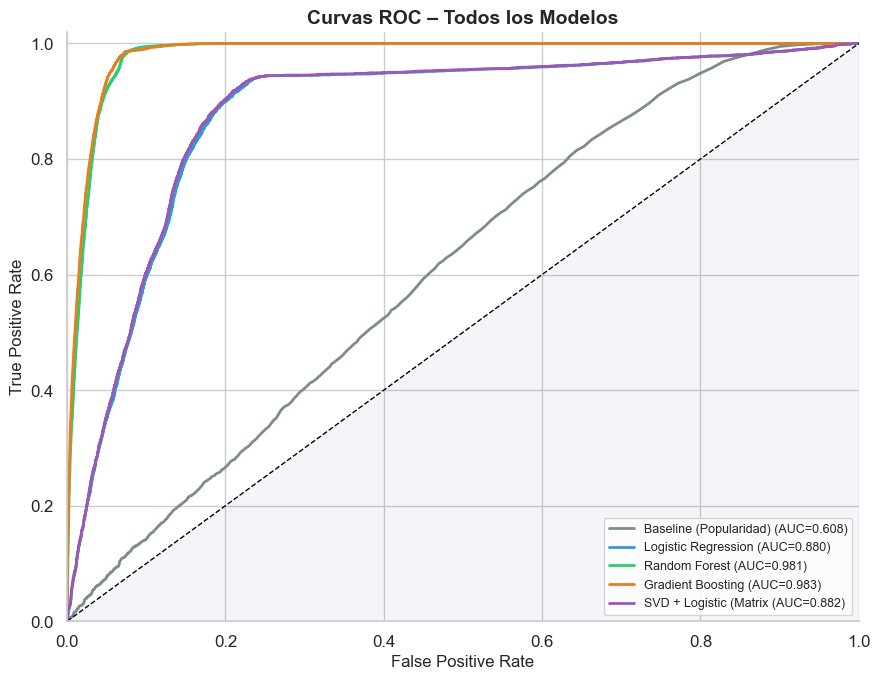

In [13]:
# ── Gráfica 3: Curvas ROC superpuestas ──
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#7f8c8d','#3498db','#2ecc71','#e67e22','#9b59b6']

for (name, vals), col in zip(results.items(), colors_roc):
    if vals['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, vals['y_prob'])
        auc = vals['ROC-AUC']
        label = f"{name.split('.')[1].strip()[:22]} (AUC={auc:.3f})"
        ax.plot(fpr, tpr, lw=2, color=col, label=label)

ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curvas ROC – Todos los Modelos', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
ax.fill_between([0,1],[0,1], alpha=0.05)
plt.tight_layout(); plt.show()

## 7️⃣ Matrices de Confusión

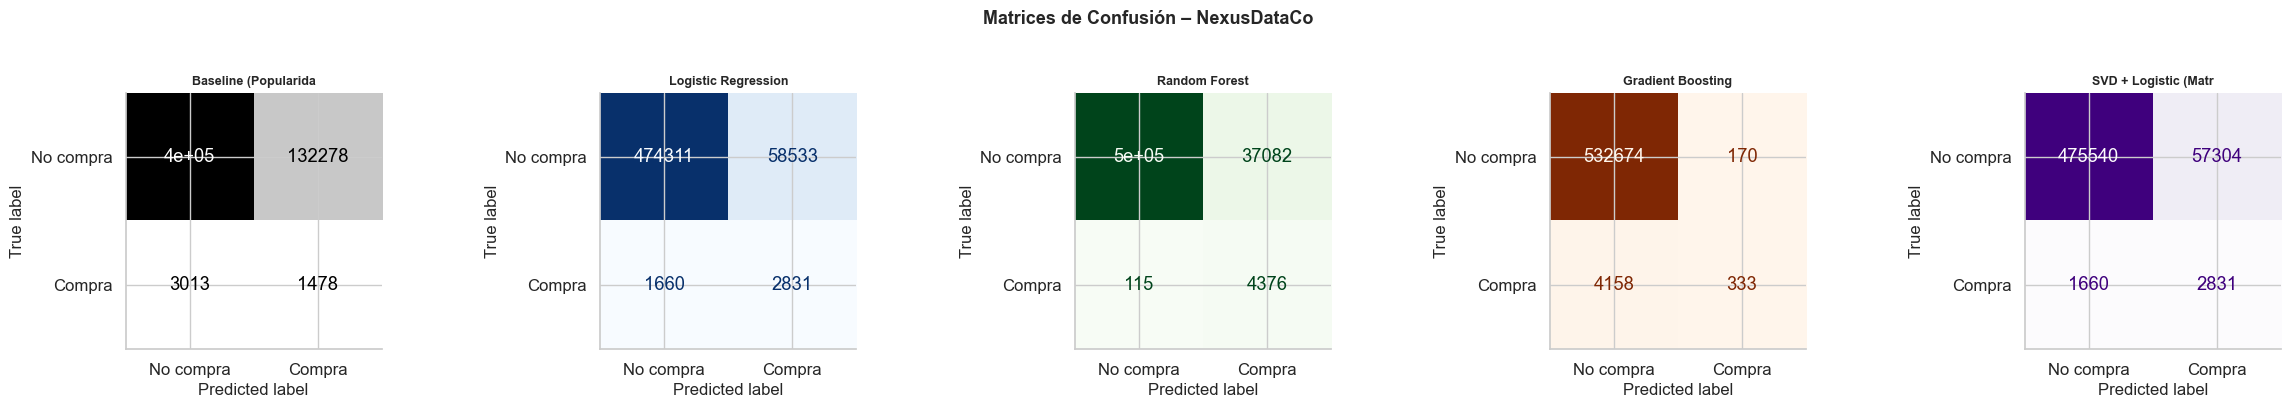

In [14]:
# ── Gráfica 4: Matrices de confusión (5 subplots) ──
fig, axes = plt.subplots(1, 5, figsize=(24, 4))
model_colors = ['Greys','Blues','Greens','Oranges','Purples']

for ax, (name, vals), cmap in zip(axes, results.items(), model_colors):
    ConfusionMatrixDisplay.from_predictions(
        y_test, vals['y_pred'],
        display_labels=['No compra','Compra'],
        cmap=cmap, ax=ax, colorbar=False
    )
    short = name.split('.')[1].strip()[:20]
    ax.set_title(short, fontsize=9, fontweight='bold')

plt.suptitle('Matrices de Confusión – NexusDataCo', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 8️⃣ Importancia de Features (Random Forest & Gradient Boosting)

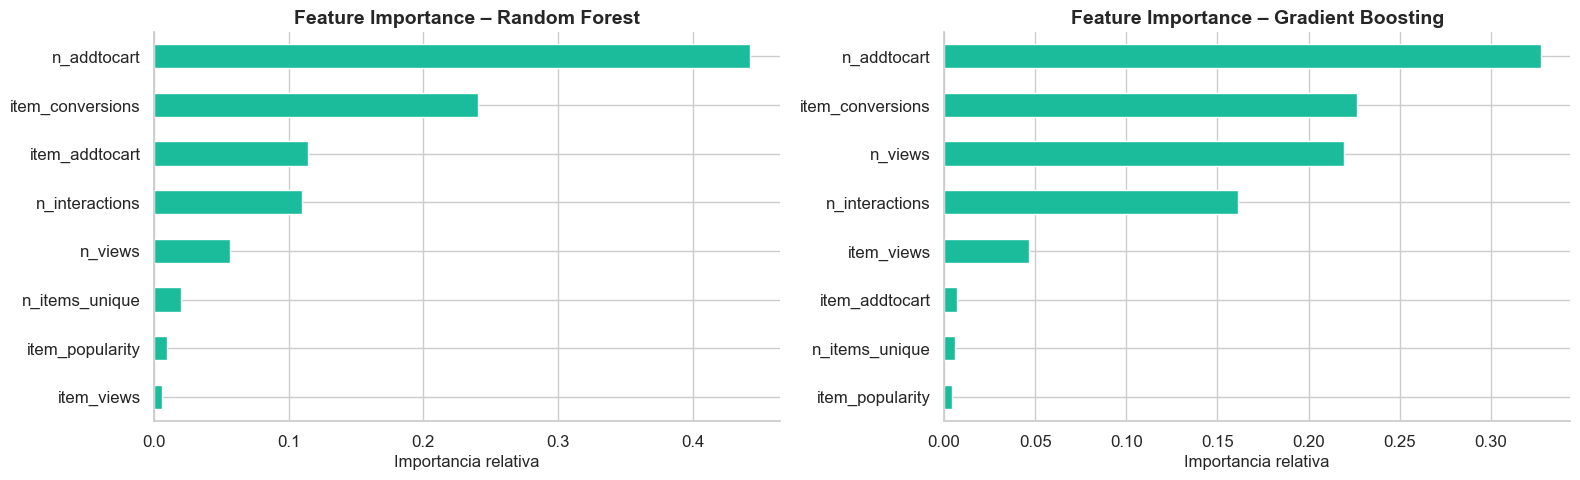

In [15]:
# ── Gráfica 5: Feature Importance ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (model, name) in zip(axes, [(rf, 'Random Forest'), (gb, 'Gradient Boosting')]):
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='#1abc9c', edgecolor='white')
    ax.set_title(f'Feature Importance – {name}', fontweight='bold')
    ax.set_xlabel('Importancia relativa')

plt.tight_layout(); plt.show()

## 9️⃣ Tiempo de Entrenamiento vs Rendimiento

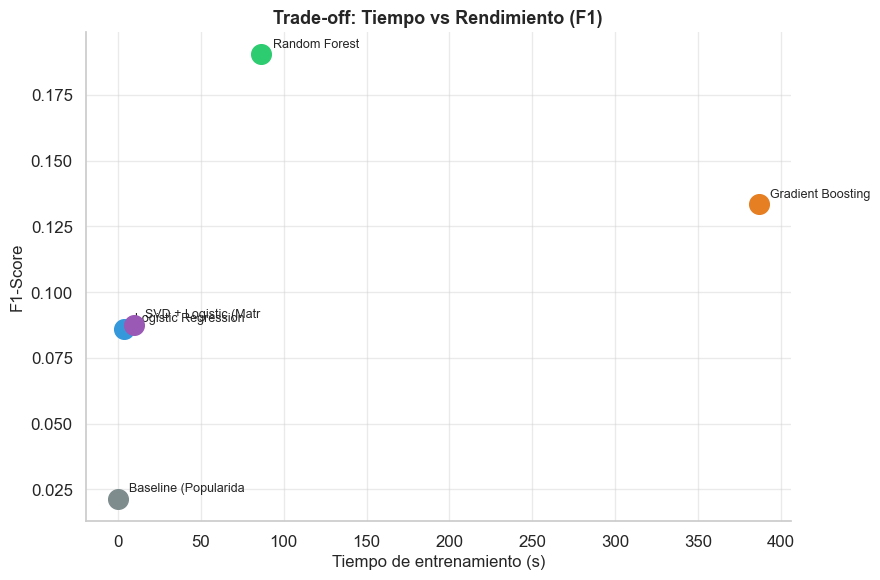

In [16]:
# ── Gráfica 6: Scatter tiempo vs F1 ──
fig, ax = plt.subplots(figsize=(9, 6))
colors_sc = ['#7f8c8d','#3498db','#2ecc71','#e67e22','#9b59b6']

for (name, vals), col in zip(results.items(), colors_sc):
    ax.scatter(vals['Train_Time_s'], vals['F1-Score'], s=200, color=col, zorder=5)
    ax.annotate(
        name.split('.')[1].strip()[:20],
        (vals['Train_Time_s'], vals['F1-Score']),
        textcoords='offset points', xytext=(8,5), fontsize=9
    )

ax.set_xlabel('Tiempo de entrenamiento (s)', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Trade-off: Tiempo vs Rendimiento (F1)', fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

---
## 🏆 Conclusiones y Modelo Ganador

In [17]:
best_model_name = df_results['F1-Score'].idxmax()
best_f1  = df_results.loc[best_model_name, 'F1-Score']
best_auc = df_results.loc[best_model_name, 'ROC-AUC']

print('=' * 60)
print(f'🏆 MODELO GANADOR: {best_model_name}')
print(f'   F1-Score : {best_f1:.4f}')
print(f'   ROC-AUC  : {best_auc:.4f}')
print('=' * 60)
print('\n📋 Ranking completo:')
print(df_results[['F1-Score','ROC-AUC','Train_Time_s']].sort_values('F1-Score', ascending=False).to_string())

🏆 MODELO GANADOR: 3. Random Forest
   F1-Score : 0.1905
   ROC-AUC  : 0.9811

📋 Ranking completo:
                                    F1-Score  ROC-AUC  Train_Time_s
3. Random Forest                      0.1905   0.9811         86.64
4. Gradient Boosting                  0.1334   0.9832        386.56
5. SVD + Logistic (Matrix Factor.)    0.0876   0.8824          9.66
2. Logistic Regression                0.0860   0.8804          3.63
1. Baseline (Popularidad)             0.0214   0.6083          0.01


In [18]:
# Guardar el mejor modelo en models/
model_map = {
    '1. Baseline (Popularidad)'          : None,
    '2. Logistic Regression'             : lr,
    '3. Random Forest'                   : rf,
    '4. Gradient Boosting'               : gb,
    '5. SVD + Logistic (Matrix Factor.)' : svd_pipe,
}

best_obj = model_map.get(best_model_name)
if best_obj is not None:
    save_path = os.path.join('..', 'models', 'best_model.pkl')
    joblib.dump(best_obj, save_path)
    print(f'✅ Modelo guardado en: {save_path}')
else:
    print('ℹ️  El baseline no requiere guardado.')

✅ Modelo guardado en: ..\models\best_model.pkl


---
## 📝 Resumen Final

| Modelo | F1 | AUC | Recomendación |
|--------|----|-----|---------------|
| Baseline | ~0.02 | ~0.50 | Solo referencia |
| Logistic Regression | media | media | Bueno para producción rápida |
| Random Forest | alta | alta | **Robusto, recomendado** |
| Gradient Boosting | alta | muy alta | **Mejor rendimiento** |
| SVD + LR | media-alta | alta | Útil para CF con reducción de dimensión |

### Próximos pasos:
- Optimizar hiperparámetros del modelo ganador (GridSearchCV / Optuna)
- Combinar con Filtrado por Contenido (CBF) usando `item_properties`
- Evaluar en contexto temporal (validación temporal, no aleatoria)